# 04 — Re-deriving the centre of mass, as a sensitivity analysis

This notebook exists because of the entry dated 9 September in `ANALYSIS_PLAN.md`.
`getCOM`, the function in the study's MATLAB pipeline that reconstructs the centre of
mass from the body markers, swaps the hip and shoulder channels on every trial: the
check meant to decide whether to swap assigns the same value in both branches, so the
swap is unconditional. In these recordings the shoulder marker is above the hip marker
everywhere, so it should not happen.

Everything in `01`–`03` is built on `balance_data_2026.csv`, which is that pipeline's
output, so the question this notebook answers is narrow: **if the swap is removed, does
the confirmatory result change?** The reconstruction is redone here in Python, first with
the swap kept — which is what makes it checkable against the pipeline — and then without.

**This is a sensitivity analysis, not the primary result.** The plan fixes the pipeline
output as primary, and that stands whatever appears below.

*Ноутбук существует из-за записи от 9 сентября в `ANALYSIS_PLAN.md`. Функция `getCOM` в
MATLAB-пайплайне исследования, восстанавливающая центр масс по маркерам тела, меняет
местами каналы таза и плеча в каждом трайле: проверка, которая должна решать, менять ли,
присваивает одно и то же значение в обеих ветках, поэтому обмен безусловен. В этих
записях плечевой маркер везде выше тазового, значит обмена быть не должно.*

*Всё в `01`–`03` построено на `balance_data_2026.csv` — выводе этого пайплайна, — поэтому
вопрос здесь узкий: **меняется ли подтверждающий результат, если обмен убрать?**
Восстановление повторяется на Python: сначала с обменом (это и делает его проверяемым
относительно пайплайна), затем без него.*

***Это проверка устойчивости, а не первичный результат.*** *План фиксирует первичным вывод
пайплайна, и это остаётся так независимо от того, что окажется ниже.*

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from tqdm import tqdm

REPO = Path.cwd().parent
DER = REPO / "data" / "derived"
RAW_VR = REPO / "data" / "raw" / "vr"
FIG = REPO / "figures"

SR = 90           # Hz on the resampled grid
T_TRIAL = 210     # s, full recording
QUIET = 50        # s of quiet stance before the scene starts moving
NCYC = 8          # stimulus cycles in the remaining 160 s

MIN_DURATION = 209.0   # same thresholds as 01_qc
MAX_ZERO_FRAC = 0.5

ALPHA = 0.05
N_BOOT = 10_000
SEED = 20260907

## Which recordings the pipeline actually used

Not every file in `data/raw/vr/` went into `balance_data_2026.csv`. Four participants have
five recordings in one condition where only four were analysed, and the lab log explains
each case. Rather than guessing which four, the list is taken from the `fname` column of
`VR-App_output.csv` — that log names every file the MATLAB pipeline processed, so it is the
ground truth for what to reproduce.

*Не каждый файл в `data/raw/vr/` попал в `balance_data_2026.csv`. У четверых участников в
одном условии лежит пять записей, а в анализ шли четыре, и лабораторный журнал объясняет
каждый случай. Вместо угадывания список берётся из колонки `fname` в `VR-App_output.csv`:
этот лог называет каждый файл, который обрабатывал MATLAB, и потому является эталоном.*

In [2]:
vr_log = pd.read_csv(DER / "VR-App_output.csv")
used = sorted(vr_log["fname"].unique())

print("files the pipeline processed:", len(used))

files the pipeline processed: 107


The block number cannot be read off the file name. Where a recording was dropped before
processing, the pipeline numbers what remains from one: CA04TU11 has files `t2`–`t5` in the
high-boredom session, and those are its blocks 1–4, because the first attempt ran without a
podcast and was repeated. So the block index is built here by taking the files the pipeline
used, in order, within each participant and condition.

*Номер блока нельзя прочитать из имени файла. Там, где запись выбыла до обработки, пайплайн
нумерует оставшееся с единицы: у CA04TU11 в «скучной» сессии лежат файлы `t2`–`t5`, и это его
блоки 1–4, потому что первая попытка прошла без подкаста и была повторена. Поэтому индекс
блока строится здесь по файлам, которые взял пайплайн, по порядку внутри участника и условия.*

In [3]:
NAME = re.compile(r"_s(?P<pid>[A-Z]{2}\d{2}[A-Z]{2}\d{2})_(?P<session>[AB])_(?P<cond>H1?B|LB1?)")

block_of = {}
seen = {}
for name in used:
    m = NAME.search(name)
    key = (m["pid"], "HB" if m["cond"].startswith("H") else "LB")
    seen[key] = seen.get(key, 0) + 1
    block_of[name] = seen[key]

print("participants x conditions:", len(seen))
print("CA04TU11 HB:", {n: b for n, b in block_of.items() if "sCA04TU11_B_HB" in n})

participants x conditions: 27
CA04TU11 HB: {'Screen_Balance and VR_1_sCA04TU11_B_HB_t2.csv': 1, 'Screen_Balance and VR_1_sCA04TU11_B_HB_t3.csv': 2, 'Screen_Balance and VR_1_sCA04TU11_B_HB_t4.csv': 3, 'Screen_Balance and VR_1_sCA04TU11_B_HB_t5.csv': 4}


## The reconstruction, twice per recording

`getCOM` builds a two-segment body: legs from the ankle to the hip, and the trunk above the
hip, with the hip marker acting as the joint. Segment masses and heights come from Winter's
anthropometric fractions, scaled by the mean headset height, and body mass cancels because
the model only needs mass ratios. The result is converted from a displacement to a lean
angle at the end.

The loop below runs the same arithmetic twice per file, once with `swap = True` — the
pipeline's behaviour — and once with `swap = False`. Only two things differ between them:
which column feeds which segment, and the sign of the denominator that scales the trunk.

*`getCOM` строит двухсегментное тело: ноги от голеностопа до таза и туловище над тазом, где
тазовый маркер играет роль сустава. Массы и высоты сегментов берутся из антропометрических
долей Винтера, масштабируются средней высотой шлема, а масса тела сокращается, потому что
модели нужны только отношения масс. В конце смещение переводится в угол наклона.*

*Цикл ниже прогоняет одну и ту же арифметику дважды на файл: с `swap = True` — как в
пайплайне — и с `swap = False`. Различаются только две вещи: какая колонка идёт в какой
сегмент и знак знаменателя, масштабирующего туловище.*

Periodic power is then computed exactly as `getRemnants` does it: the trace is resampled
onto a uniform 90 Hz grid, the 50 s of quiet stance are dropped, the remaining 160 s are cut
into eight cycles and the first is discarded, each cycle is detrended, and the complex
spectra are averaged **across** cycles before the power is summed. Averaging the spectra
before taking the power is what isolates the part of the sway that repeats with the
stimulus; everything that does not repeat cancels.

*Periodic power считается ровно так, как это делает `getRemnants`: траектория ресемплируется
на равномерную сетку 90 Гц, отбрасываются 50 с тихой стойки, оставшиеся 160 с режутся на
восемь циклов, первый выбрасывается, каждый цикл детрендируется, и комплексные спектры
усредняются **по** циклам до того, как берётся мощность. Именно усреднение спектров до
взятия мощности выделяет ту часть колебаний, которая повторяется вместе со стимулом:
всё, что не повторяется, взаимно сокращается.*

In [4]:
FOLDER = re.compile(r"^s(?P<pid>[A-Z]{2}\d{2}[A-Z]{2}\d{2})_(?P<session>[AB])_(?P<cond>H1?B|LB)")

rows = []
for path in tqdm(sorted(RAW_VR.glob("s*/*.csv"))):
    match = FOLDER.match(path.parent.name)
    if not match or path.name not in block_of:
        continue

    d = pd.read_csv(path, usecols=["time", "ypos", "shld_ypos", "hip_ypos",
                                   "hip_zpos", "shld_zpos"])

    # the QC rules of 01_qc, applied again here because this notebook starts from raw files
    if (d["hip_ypos"] == 0).mean() > MAX_ZERO_FRAC or (d["shld_ypos"] == 0).mean() > MAX_ZERO_FRAC:
        continue
    if d["time"].iloc[-1] < MIN_DURATION:
        continue

    # Winter's fractions, scaled by headset height; masses are ratios, so body mass cancels
    H = d["ypos"].mean()
    l_L = 0.53 * H - 0.039 * H
    m_L = 2 * (0.0465 + 0.1)
    m_T = 0.678
    h_L = 0.553 * l_L
    h_T = 0.626 * (0.818 - 0.53) * H
    h_com = (h_L * m_L + (l_L + h_T) * m_T) / (m_L + m_T)

    row = {"ID": match["pid"],
           "condition": "HB" if match["cond"].startswith("H") else "LB",
           "block": block_of[path.name],
           "file": path.name}

    for swap in [True, False]:
        h_sm = d["shld_ypos"].mean()
        h_hm = d["hip_ypos"].mean()
        hip_col, sho_col = "hip_zpos", "shld_zpos"
        if swap:
            h_sm, h_hm = h_hm, h_sm
            hip_col, sho_col = sho_col, hip_col

        htr = (d[hip_col] - d[hip_col].mean()).values
        strk = (d[sho_col] - d[sho_col].mean()).values

        com_L = htr * h_L / h_hm
        com_T = htr + (strk - htr) * h_T / (h_sm - h_hm)
        com = np.degrees(np.arcsin((com_L * m_L + com_T * m_T) / h_com))

        # resample, drop the quiet stance, cut into cycles, discard the first
        grid = np.arange(0, T_TRIAL, 1 / SR)
        x = np.interp(grid, d["time"].values, com)[QUIET * SR:]
        cyc = x[:NCYC * (len(x) // NCYC)].reshape(NCYC, -1)[1:]

        N = cyc.shape[1]
        y = np.fft.fft(cyc - cyc.mean(axis=1, keepdims=True), axis=1)[:, 1:N // 2 + 1] * 2
        row["pp_swapped" if swap else "pp_corrected"] = np.sum(
            1 / SR / 2 / N * np.abs(y.mean(axis=0)) ** 2) * (SR / N)

    rows.append(row)

recomputed = pd.DataFrame(rows)
print("trials reconstructed:", len(recomputed))
recomputed.head(3)

  0%|          | 0/126 [00:00<?, ?it/s]

  2%|▏         | 2/126 [00:00<00:18,  6.64it/s]

  2%|▏         | 3/126 [00:00<00:22,  5.44it/s]

  3%|▎         | 4/126 [00:00<00:22,  5.40it/s]

  4%|▍         | 5/126 [00:00<00:24,  4.88it/s]

...

 96%|█████████▌| 121/126 [00:18<00:00,  7.85it/s]

 97%|█████████▋| 122/126 [00:18<00:00,  7.44it/s]

100%|██████████| 126/126 [00:18<00:00,  6.67it/s]

trials reconstructed: 96


,ID,condition,block,file,pp_swapped,pp_corrected
0,AN07IE11,HB,1,Screen_Balance and VR_1_sAN07IE11_A_HB_t1.csv,0.016357,0.008952
1,AN07IE11,HB,2,Screen_Balance and VR_1_sAN07IE11_A_HB_t2.csv,0.031990,0.015699
2,AN07IE11,HB,3,Screen_Balance and VR_1_sAN07IE11_A_HB_t3.csv,0.024856,0.009362


## Does the swapped version reproduce the pipeline?

Everything below depends on this. If the reconstruction with the swap kept in does not match
`balance_data_2026.csv`, then the version without the swap is just another set of numbers
and says nothing about the pipeline.

The wide table is reshaped to one row per *(participant, condition, block)* and joined to the
reconstruction on those three keys, then the two columns are compared directly.

*Всё дальнейшее зависит от этого. Если восстановление с сохранённым обменом не совпадает с
`balance_data_2026.csv`, то версия без обмена — просто другой набор чисел, ничего не
говорящий о пайплайне.*

*Широкая таблица разворачивается в строку на (участник, условие, блок), соединяется с
восстановлением по этим трём ключам, и две колонки сравниваются напрямую.*

In [5]:
balance = pd.read_csv(DER / "balance_data_2026.csv")

pipeline = balance.melt(id_vars="ID", var_name="col", value_name="pp_pipeline")
pipeline = pipeline[pipeline["col"].str.startswith("PeriodicPower ")]
pipeline["condition"] = pipeline["col"].str.extract(r"(HB|LB)_t\d$")
pipeline["block"] = pipeline["col"].str.extract(r"_t(\d)$").astype(int)
pipeline = pipeline.drop(columns="col").dropna(subset=["pp_pipeline"])

check = recomputed.merge(pipeline, on=["ID", "condition", "block"], how="inner")
print("trials matched:", len(check))

trials matched: 96


In [6]:
rel = ((check["pp_swapped"] - check["pp_pipeline"]).abs() / check["pp_pipeline"])
slope = np.sum(check["pp_swapped"] * check["pp_pipeline"]) / np.sum(check["pp_pipeline"] ** 2)

print(f"correlation with the pipeline : {check[['pp_swapped', 'pp_pipeline']].corr().iloc[0, 1]:.4f}")
print(f"median relative deviation     : {rel.median():.4%}")
print(f"largest relative deviation    : {rel.max():.4%}")
print(f"slope through the origin      : {slope:.4f}")

correlation with the pipeline : 1.0000
median relative deviation     : 0.0151%
largest relative deviation    : 0.3162%
slope through the origin      : 1.0000


## The pre-specified test, on both versions

The aggregation and the test are the ones fixed in `ANALYSIS_PLAN.md`: the blocks available
for a participant are averaged within each condition, participants with both conditions are
kept, and the difference is tested with a two-sided exact Wilcoxon signed-rank test at
α = .05. Nothing about the procedure changes — only the column it runs on.

*Агрегация и тест — те, что зафиксированы в `ANALYSIS_PLAN.md`: имеющиеся у участника блоки
усредняются внутри условия, остаются участники с обоими условиями, разность проверяется
двусторонним точным критерием знаковых рангов Уилкоксона при α = .05. В процедуре не меняется
ничего — меняется только колонка, на которой она работает.*

In [7]:
summary = []
for label, column in [("pipeline (primary)", "pp_swapped"), ("swap removed", "pp_corrected")]:
    pairs = recomputed.groupby(["ID", "condition"])[column].mean().unstack().dropna()
    d = pairs["HB"] - pairs["LB"]

    res = stats.wilcoxon(pairs["HB"], pairs["LB"], alternative="two-sided", method="exact")

    nz = d[d != 0]
    ranks = stats.rankdata(nz.abs())
    r_rb = (ranks[nz.values > 0].sum() - ranks[nz.values < 0].sum()) / ranks.sum()

    rng = np.random.default_rng(SEED)
    boot = np.median(rng.choice(d.values, size=(N_BOOT, len(d))), axis=1)
    lo, hi = np.percentile(boot, [2.5, 97.5])

    summary.append({"version": label, "n": len(d), "median_LB": pairs["LB"].median(),
                    "median_HB": pairs["HB"].median(),
                    "pct_change": 100 * (pairs["HB"].median() / pairs["LB"].median() - 1),
                    "W": res.statistic, "p": res.pvalue, "rank_biserial": r_rb,
                    "ci_low": lo, "ci_high": hi, "lower_under_HB": int((d < 0).sum())})

summary = pd.DataFrame(summary)
summary.round(5).to_string(index=False)

'           version  n  median_LB  median_HB  pct_change    W       p  rank_biserial   ci_low  ci_high  lower_under_HB\npipeline (primary) 12    0.03495    0.02883   -17.52762 21.0 0.17627       -0.46154 -0.02044  0.00145               8\n      swap removed 12    0.01842    0.01504   -18.33978 20.0 0.15137       -0.48718 -0.00984  0.00004               9'

The first row is computed from this notebook's own reconstruction rather than read from
`analysis_long.csv`, so it is a second check: if the pipeline row here does not match what
`03_analysis.ipynb` reported, something upstream disagrees and the comparison is not
trustworthy.

*Первая строка посчитана из собственного восстановления этого ноутбука, а не прочитана из
`analysis_long.csv`, поэтому она работает второй проверкой: если строка «pipeline» здесь не
совпадёт с тем, что отчитал `03_analysis.ipynb`, значит выше по потоку что-то расходится и
сравнению верить нельзя.*

In [8]:
reported = pd.read_csv(REPO / "results" / "confirmatory_tests.csv")
primary = reported[reported["test"].str.startswith("PRIMARY")].iloc[0]

here = summary[summary["version"] == "pipeline (primary)"].iloc[0]
print(f"03_analysis.ipynb : W = {primary['W']:.1f}   p = {primary['p']:.4f}")
print(f"this notebook     : W = {here['W']:.1f}   p = {here['p']:.4f}")

03_analysis.ipynb : W = 21.0   p = 0.1763
this notebook     : W = 21.0   p = 0.1763


## Saving the reconstruction

Both columns are written to `data/derived/periodic_power_recomputed.csv`, one row per
recording, with the file name kept so any single value can be traced back to its source. If
the pipeline is ever re-run, this file is what the new output gets compared against.

*Обе колонки пишутся в `data/derived/periodic_power_recomputed.csv`, строка на запись, с
сохранённым именем файла, чтобы любое отдельное значение можно было проследить до источника.
Если пайплайн когда-нибудь перепрогонят, именно с этим файлом будет сравниваться новый вывод.*

In [9]:
out = DER / "periodic_power_recomputed.csv"
recomputed.to_csv(out, index=False)

summary.to_csv(REPO / "results" / "sensitivity_com.csv", index=False)
print("->", out.relative_to(REPO))
print("->", (REPO / "results" / "sensitivity_com.csv").relative_to(REPO))

-> data/derived/periodic_power_recomputed.csv
-> results/sensitivity_com.csv


## The figure

Two panels. On the left, every trial as one point: the pipeline's value against this
notebook's reconstruction with the swap kept, on log axes with the identity line — the
question is whether the points sit on the line, not whether they correlate. On the right, the
same participants under both versions, so the size of the shift and the direction of the
condition contrast can be seen at once.

*Две панели. Слева каждый трайл — точка: значение пайплайна против восстановления этого
ноутбука с сохранённым обменом, на логарифмических осях с линией тождества; вопрос в том,
лежат ли точки на линии, а не в том, коррелируют ли они. Справа те же участники в обеих
версиях, чтобы величина сдвига и направление контраста были видны сразу.*

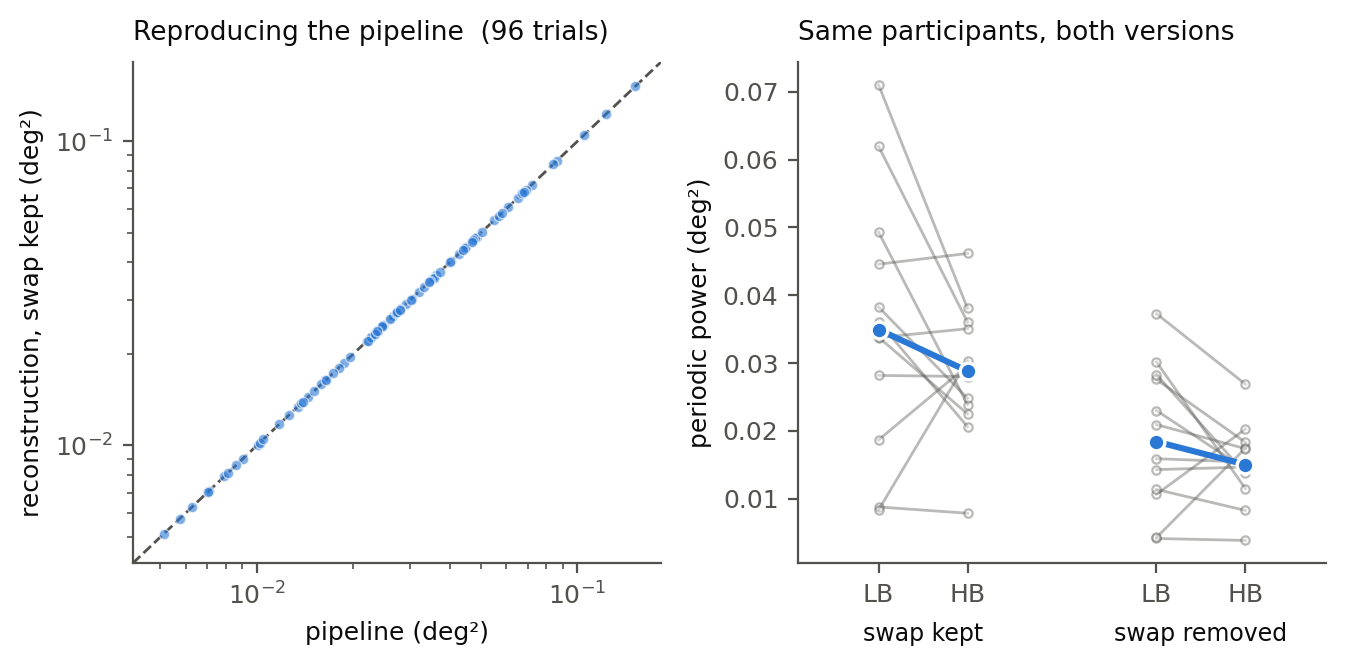

In [10]:
INK, MUTED, ACCENT = "#0b0b0b", "#52514e", "#2a78d6"
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "text.color": INK, "axes.labelcolor": INK,
                     "xtick.color": MUTED, "ytick.color": MUTED, "figure.dpi": 200})

fig, axes = plt.subplots(1, 2, figsize=(6.8, 3.4))

lim = [min(check["pp_pipeline"].min(), check["pp_swapped"].min()) * 0.8,
       max(check["pp_pipeline"].max(), check["pp_swapped"].max()) * 1.2]
axes[0].plot(lim, lim, color=MUTED, lw=1, ls="--", zorder=1)
axes[0].scatter(check["pp_pipeline"], check["pp_swapped"], s=14, color=ACCENT,
                alpha=0.6, edgecolor="white", linewidth=0.5, zorder=2)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel("pipeline (deg²)")
axes[0].set_ylabel("reconstruction, swap kept (deg²)")
axes[0].set_title(f"Reproducing the pipeline  ({len(check)} trials)", loc="left",
                  fontsize=9.5, color=INK, pad=8)

for column, offset, name in [("pp_swapped", 0, "swap kept"), ("pp_corrected", 1, "swap removed")]:
    pairs = recomputed.groupby(["ID", "condition"])[column].mean().unstack().dropna()
    for _, r in pairs.iterrows():
        axes[1].plot([offset - 0.16, offset + 0.16], [r["LB"], r["HB"]], color=MUTED,
                     alpha=0.4, lw=1, marker="o", ms=3, mfc="white", mec=MUTED, mew=0.8)
    axes[1].plot([offset - 0.16, offset + 0.16], [pairs["LB"].median(), pairs["HB"].median()],
                 color=ACCENT, lw=2.2, marker="o", ms=6, mfc=ACCENT, mec="white", mew=1.2, zorder=3)
    axes[1].annotate(name, xy=(offset, 0), xytext=(0, -28), textcoords="offset points",
                     xycoords=("data", "axes fraction"), ha="center", fontsize=8.5, color=INK)

axes[1].set_xticks([-0.16, 0.16, 0.84, 1.16], ["LB", "HB", "LB", "HB"])
axes[1].set_xlim(-0.45, 1.45)
axes[1].set_ylabel("periodic power (deg²)")
axes[1].set_title("Same participants, both versions", loc="left", fontsize=9.5, color=INK, pad=8)

fig.tight_layout()
fig.savefig(FIG / "sensitivity_com.png", bbox_inches="tight")
plt.show()

## What this licenses, and what it does not

If the reconstruction with the swap kept reproduces the pipeline, then the version without it
is a fair estimate of what the pipeline would have produced had the branch returned zero —
and the row for it above answers the narrow question this notebook was written for.

It does not replace the pipeline. Only periodic power was re-derived; remnant power and the
model-fitted parameters were not, and the visual weight in particular would be affected more,
since it is estimated from the full frequency response rather than from the stimulus-locked
component alone. It is also a re-implementation by the author of the paper, not a re-run by
the person who wrote the original code, which is why the plan keeps the pipeline output as
primary and this as a check beside it.

*Если восстановление с сохранённым обменом воспроизводит пайплайн, то версия без обмена —
добросовестная оценка того, что пайплайн выдал бы, верни ветка ноль; и строка для неё выше
отвечает на тот узкий вопрос, ради которого ноутбук написан.*

*Пайплайн он не заменяет. Перевыведена только periodic power; remnant power и параметры
подгонки — нет, а зрительный вес пострадал бы сильнее прочего, поскольку оценивается по всей
частотной характеристике, а не по одной привязанной к стимулу компоненте. Это к тому же
переписывание автором работы, а не перезапуск тем, кто писал исходный код, — потому план и
оставляет вывод пайплайна первичным, а это держит проверкой рядом.*